<a href="https://colab.research.google.com/github/bismarxx/Machine-Learning-I-Actividad-9/blob/main/Ejercicio1_Eigenfaces_Olivetti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reconocimiento facial con Eigenfaces (PCA)
**Dataset: Olivetti Faces (scikit-learn)**

**Objetivo:** construir un sistema de reconocimiento de rostros usando **PCA** (Análisis de Componentes Principales) para obtener las *eigenfaces*, sin usar redes neuronales.

**Idea central (Eigenfaces, Turk & Pentland, 1991):**
1. Cada imagen de rostro (64×64 px) se puede ver como un punto en un espacio de 4.096 dimensiones (un valor por píxel).
2. PCA encuentra las direcciones de mayor variabilidad entre los rostros de entrenamiento: los **componentes principales**. Como aquí las "variables" son píxeles de caras, a esos componentes se los llama **eigenfaces**.
3. Cada rostro se puede reconstruir (aproximadamente) como el rostro promedio más una combinación de eigenfaces. Esos pesos de la combinación son una **representación comprimida** del rostro (de 4.096 a, por ejemplo, 100 números).
4. Para reconocer una cara nueva, se proyecta al mismo espacio de eigenfaces y se compara con las caras de entrenamiento ya proyectadas, usando un clasificador clásico (no una red neuronal): aquí se prueban **K-Vecinos más cercanos (KNN)** y **SVM lineal**.

**Dataset:** 400 imágenes en escala de grises de 64×64 píxeles, de 40 personas (10 fotos por persona), con variaciones de iluminación, gesto y accesorios (lentes).

Contenido:
1. Carga y exploración del dataset
2. División entrenamiento / prueba
3. PCA: cálculo de las eigenfaces
4. Visualización del rostro promedio y las eigenfaces
5. Cuántos componentes usar
6. Reconstrucción de rostros
7. Clasificación: KNN y SVM sobre el espacio de eigenfaces
8. Evaluación: exactitud, matriz de confusión, ejemplos
9. Probando con una cara "desconocida"
10. Hallazgos y conclusiones

## 0. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 110

## 1. Carga y exploración del dataset

In [2]:
faces = fetch_olivetti_faces(shuffle=True, random_state=RANDOM_STATE)
X = faces.data          # (400, 4096) -> cada fila es una imagen "aplanada", valores en [0, 1]
y = faces.target        # (400,) -> id de persona, 0 a 39
images = faces.images   # (400, 64, 64) -> misma info en 2D, para visualizar

h, w = images.shape[1:]
n_muestras, n_pixeles = X.shape
n_personas = len(np.unique(y))

print(f"Muestras: {n_muestras} | Píxeles por imagen: {n_pixeles} ({h}x{w}) | Personas: {n_personas}")
print(f"Fotos por persona: {np.bincount(y)}")

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Muestras: 400 | Píxeles por imagen: 4096 (64x64) | Personas: 40
Fotos por persona: [10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10
 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10]


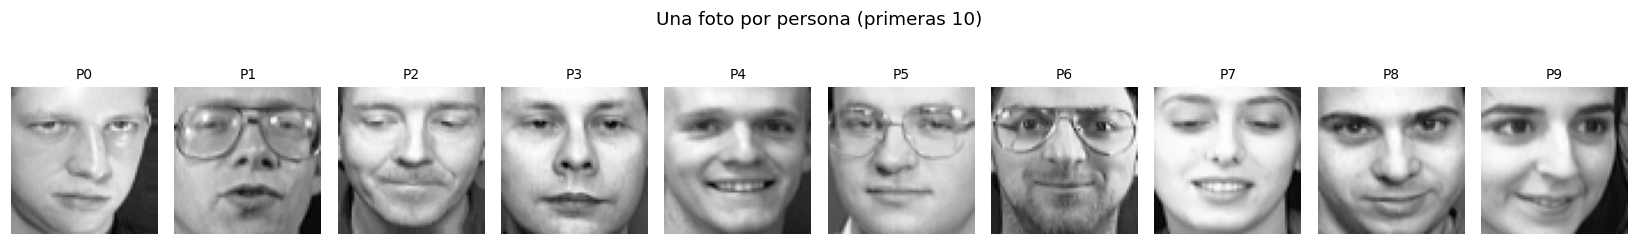

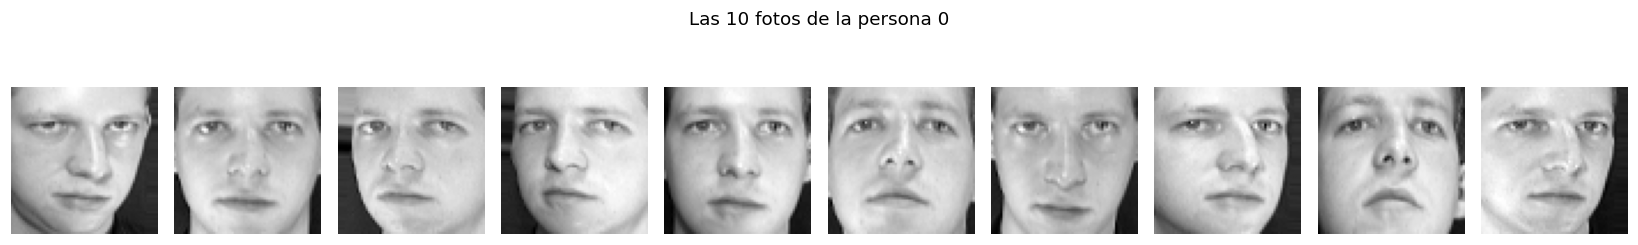

In [3]:
# Una foto de cada una de las primeras 10 personas
fig, axes = plt.subplots(1, 10, figsize=(15, 2.2))
for i, ax in enumerate(axes):
    idx = np.where(y == i)[0][0]
    ax.imshow(images[idx], cmap="gray"); ax.set_title(f"P{i}", fontsize=9); ax.axis("off")
plt.suptitle("Una foto por persona (primeras 10)", y=1.05)
plt.tight_layout(); plt.show()

# Todas las fotos de una misma persona: muestra la variabilidad (gesto, luz, lentes)
fig, axes = plt.subplots(1, 10, figsize=(15, 2.2))
idxs = np.where(y == 0)[0]
for ax, idx in zip(axes, idxs):
    ax.imshow(images[idx], cmap="gray"); ax.axis("off")
plt.suptitle("Las 10 fotos de la persona 0", y=1.05)
plt.tight_layout(); plt.show()

## 2. División entrenamiento / prueba

Se separa un 25 % de las imágenes para probar el sistema con caras que el modelo no vio en entrenamiento. La división es **estratificada** (`stratify=y`) para que cada persona quede representada en ambos conjuntos, ya que solo hay 10 fotos por persona.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print(f"Entrenamiento: {X_train.shape[0]} imágenes | Prueba: {X_test.shape[0]} imágenes")

Entrenamiento: 300 imágenes | Prueba: 100 imágenes


## 3. PCA: cálculo de las eigenfaces

El PCA se **ajusta solo con el conjunto de entrenamiento** (para no filtrar información del conjunto de prueba). `whiten=True` reescala cada componente a varianza unitaria, lo cual suele mejorar el desempeño de clasificadores basados en distancia como KNN.

Empezamos con 150 componentes (justificaremos el número en la sección 5).

In [5]:
N_COMPONENTES = 150
pca = PCA(n_components=N_COMPONENTES, whiten=True, random_state=RANDOM_STATE)
pca.fit(X_train)

eigenfaces = pca.components_.reshape((N_COMPONENTES, h, w))
print("Forma de las eigenfaces:", eigenfaces.shape)
print("Varianza explicada por los", N_COMPONENTES, "componentes:",
      round(pca.explained_variance_ratio_.sum(), 3))

Forma de las eigenfaces: (150, 64, 64)
Varianza explicada por los 150 componentes: 0.972


## 4. Visualización del rostro promedio y las eigenfaces

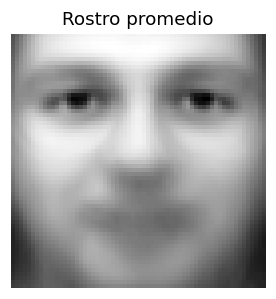

In [6]:
plt.figure(figsize=(3, 3))
plt.imshow(pca.mean_.reshape(h, w), cmap="gray")
plt.title("Rostro promedio"); plt.axis("off"); plt.show()

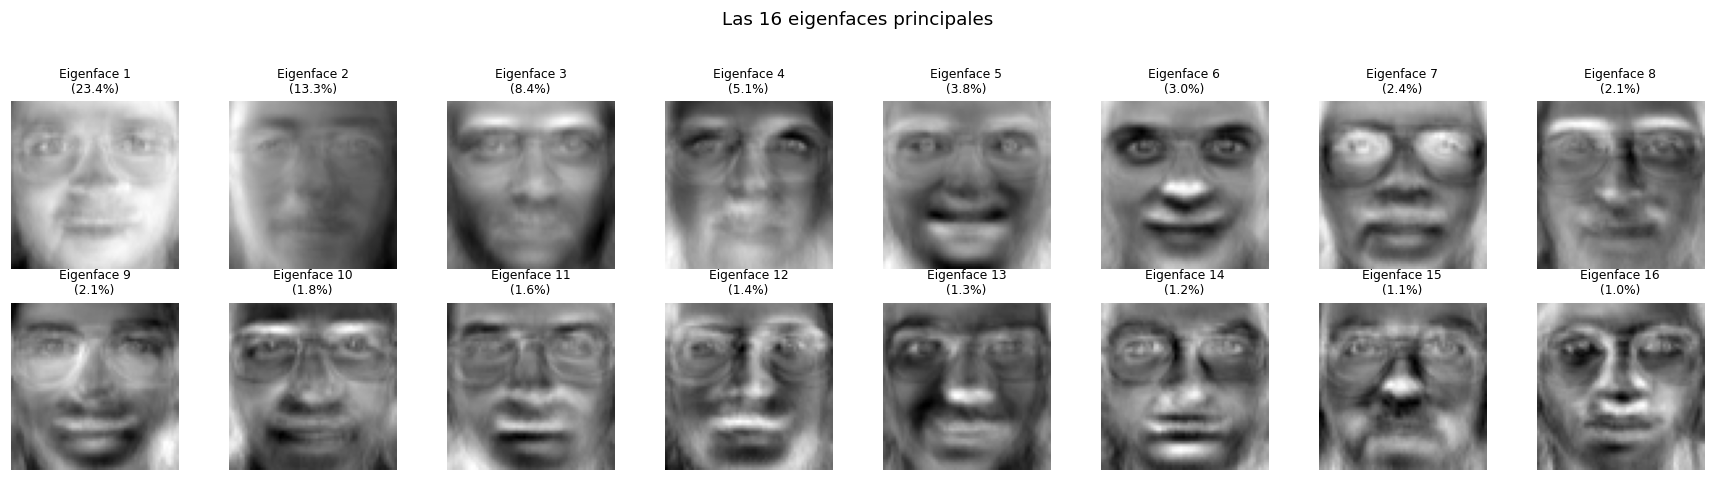

In [7]:
fig, axes = plt.subplots(2, 8, figsize=(16, 4.2))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(eigenfaces[i], cmap="gray")
    ax.set_title(f"Eigenface {i+1}\n({pca.explained_variance_ratio_[i]*100:.1f}%)", fontsize=8)
    ax.axis("off")
plt.suptitle("Las 16 eigenfaces principales", y=1.03)
plt.tight_layout(); plt.show()

Las primeras eigenfaces capturan los patrones de variación más grandes entre las caras (iluminación general, contraste, forma de la cara), y las siguientes capturan detalles cada vez más finos (ojos, boca, lentes). No representan "una persona" en particular: son direcciones del espacio de caras, y cada rostro es una combinación (positiva o negativa) de todas ellas.

## 5. ¿Cuántos componentes usar?

Se observa cuánta varianza acumulada explican los primeros *N* componentes. Es un compromiso: pocos componentes pierden información (peor reconstrucción); demasiados agregan ruido y hacen el modelo más lento.

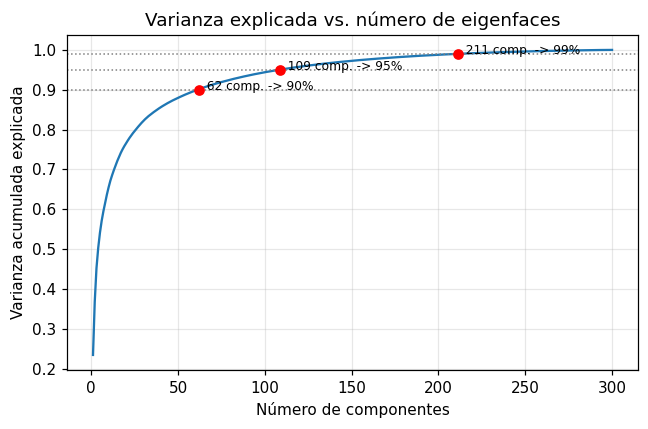

90% de la varianza  ->  62 componentes
95% de la varianza  ->  109 componentes
99% de la varianza  ->  211 componentes


In [8]:
pca_completo = PCA(random_state=RANDOM_STATE).fit(X_train)
var_acum = np.cumsum(pca_completo.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(var_acum) + 1), var_acum)
for objetivo in [0.90, 0.95, 0.99]:
    k = np.argmax(var_acum >= objetivo) + 1
    plt.axhline(objetivo, color="gray", linestyle=":", linewidth=1)
    plt.scatter([k], [objetivo], color="red", zorder=5)
    plt.annotate(f"  {k} comp. -> {objetivo*100:.0f}%", (k, objetivo), fontsize=8)
plt.xlabel("Número de componentes"); plt.ylabel("Varianza acumulada explicada")
plt.title("Varianza explicada vs. número de eigenfaces")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

for objetivo in [0.90, 0.95, 0.99]:
    k = np.argmax(var_acum >= objetivo) + 1
    print(f"{objetivo*100:.0f}% de la varianza  ->  {k} componentes")

Con ~90-120 componentes ya se explica más del 95 % de la varianza (de 4.096 píxeles originales), una compresión de más de 30 veces. Mantenemos **150 componentes** (fijados en la sección 3) como margen de seguridad, y en la sección 7 comprobamos con validación cruzada que ese valor funciona bien para clasificar.

## 6. Reconstrucción de rostros

Cada rostro se reconstruye como: `rostro promedio + suma de (peso_i × eigenface_i)`. Comparamos la imagen original con su reconstrucción usando distinto número de componentes.

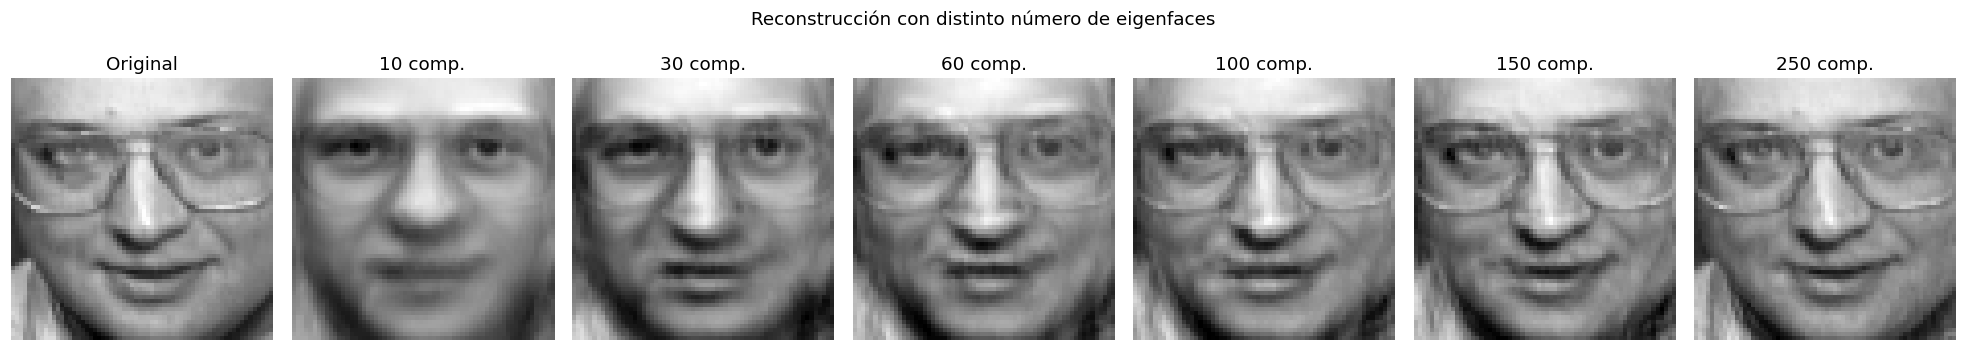

In [9]:
def reconstruir(X_fila, n_componentes):
    pca_k = PCA(n_components=n_componentes, whiten=False, random_state=RANDOM_STATE).fit(X_train)
    pesos = pca_k.transform(X_fila.reshape(1, -1))
    return pca_k.inverse_transform(pesos).reshape(h, w)

idx_ejemplo = 3
niveles = [10, 30, 60, 100, 150, 250]

fig, axes = plt.subplots(1, len(niveles) + 1, figsize=(18, 3))
axes[0].imshow(X_test[idx_ejemplo].reshape(h, w), cmap="gray")
axes[0].set_title("Original"); axes[0].axis("off")
for ax, n in zip(axes[1:], niveles):
    ax.imshow(reconstruir(X_test[idx_ejemplo], n), cmap="gray")
    ax.set_title(f"{n} comp."); ax.axis("off")
plt.suptitle("Reconstrucción con distinto número de eigenfaces", y=1.05)
plt.tight_layout(); plt.show()

Con pocos componentes la cara se ve borrosa/genérica; a partir de ~60-100 componentes ya es difícil distinguirla de la original a simple vista.

## 7. Clasificación: KNN y SVM sobre el espacio de eigenfaces

Ya con los rostros proyectados a 150 números (en vez de 4.096 píxeles), se entrena un clasificador **no neuronal** para predecir la identidad. Se comparan dos opciones clásicas:
- **KNN**: asigna la identidad de la cara de entrenamiento más cercana en el espacio de eigenfaces (el enfoque *original* de Eigenfaces).
- **SVM lineal**: separa las clases con hiperplanos; suele funcionar muy bien en este tipo de problema.

Se usa `GridSearchCV` con validación cruzada para elegir hiperparámetros usando **solo el conjunto de entrenamiento**.

In [10]:
Z_train = pca.transform(X_train)
Z_test = pca.transform(X_test)
print("Forma de las caras proyectadas:", Z_train.shape, "(antes:", X_train.shape, ")")

Forma de las caras proyectadas: (300, 150) (antes: (300, 4096) )


In [11]:
# --- KNN ---
knn_grid = GridSearchCV(KNeighborsClassifier(),
                         {"n_neighbors": [1, 3, 5, 7], "weights": ["uniform", "distance"]},
                         cv=5, scoring="accuracy")
knn_grid.fit(Z_train, y_train)
print("Mejor KNN:", knn_grid.best_params_, "| accuracy CV:", round(knn_grid.best_score_, 3))

# --- SVM lineal ---
svm_grid = GridSearchCV(SVC(kernel="linear"),
                         {"C": [0.1, 1, 10, 100]},
                         cv=5, scoring="accuracy")
svm_grid.fit(Z_train, y_train)
print("Mejor SVM :", svm_grid.best_params_, "| accuracy CV:", round(svm_grid.best_score_, 3))

modelos = {"KNN": knn_grid.best_estimator_, "SVM lineal": svm_grid.best_estimator_}

Mejor KNN: {'n_neighbors': 1, 'weights': 'uniform'} | accuracy CV: 0.637
Mejor SVM : {'C': 0.1} | accuracy CV: 0.8


## 8. Evaluación en el conjunto de prueba

In [12]:
resumen = {}
predicciones = {}
for nombre, clf in modelos.items():
    y_pred = clf.predict(Z_test)
    predicciones[nombre] = y_pred
    resumen[nombre] = accuracy_score(y_test, y_pred)
    print(f"--- {nombre} ---")
    print(f"Exactitud en prueba: {resumen[nombre]:.3f}")

pd.Series(resumen, name="Exactitud (test)").round(3).to_frame()

--- KNN ---
Exactitud en prueba: 0.860
--- SVM lineal ---
Exactitud en prueba: 0.970


,Exactitud (test)
KNN,0.86
SVM lineal,0.97


In [13]:
mejor_nombre = max(resumen, key=resumen.get)
mejor_pred = predicciones[mejor_nombre]
print(f"Mejor modelo: {mejor_nombre}\n")
print(classification_report(y_test, mejor_pred, zero_division=0))

Mejor modelo: SVM lineal

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3
           2       1.00      0.33      0.50         3
           3       1.00      1.00      1.00         3
           4       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         2
 

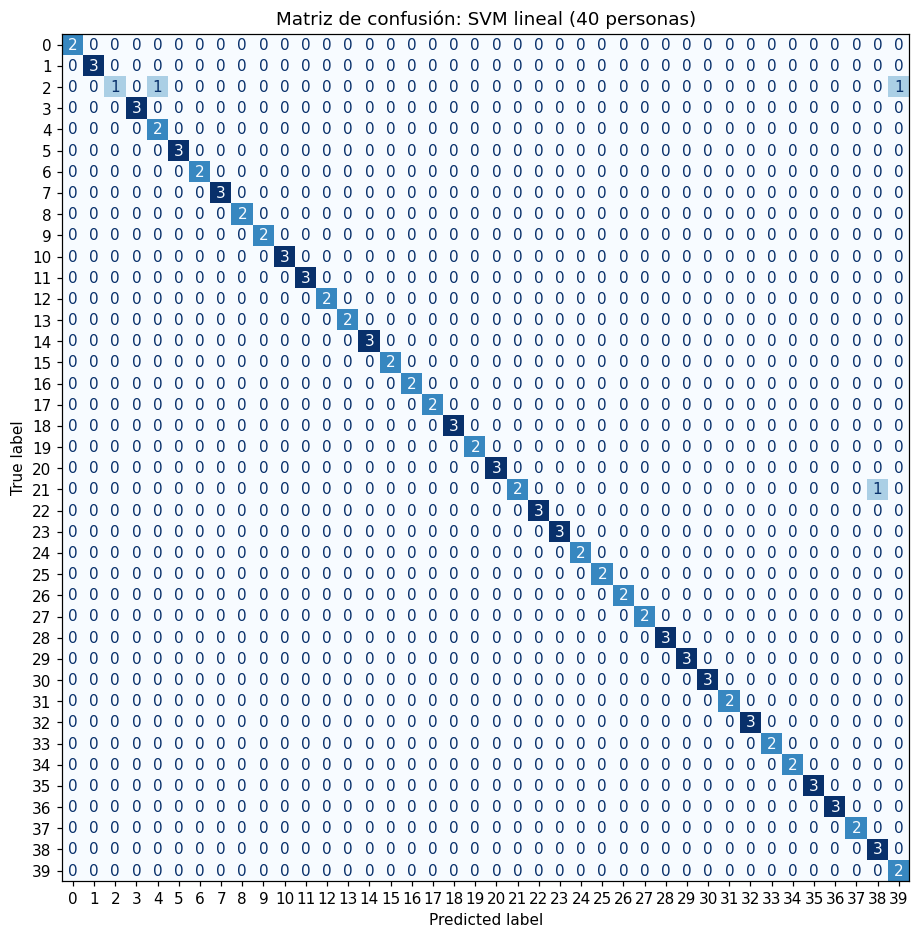

Errores: 3 de 100 (3.0%)


In [14]:
cm = confusion_matrix(y_test, mejor_pred)
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matriz de confusión: {mejor_nombre} ({len(np.unique(y))} personas)")
plt.show()

errores = np.where(mejor_pred != y_test)[0]
print(f"Errores: {len(errores)} de {len(y_test)} ({len(errores)/len(y_test)*100:.1f}%)")

### Ejemplos de aciertos y errores

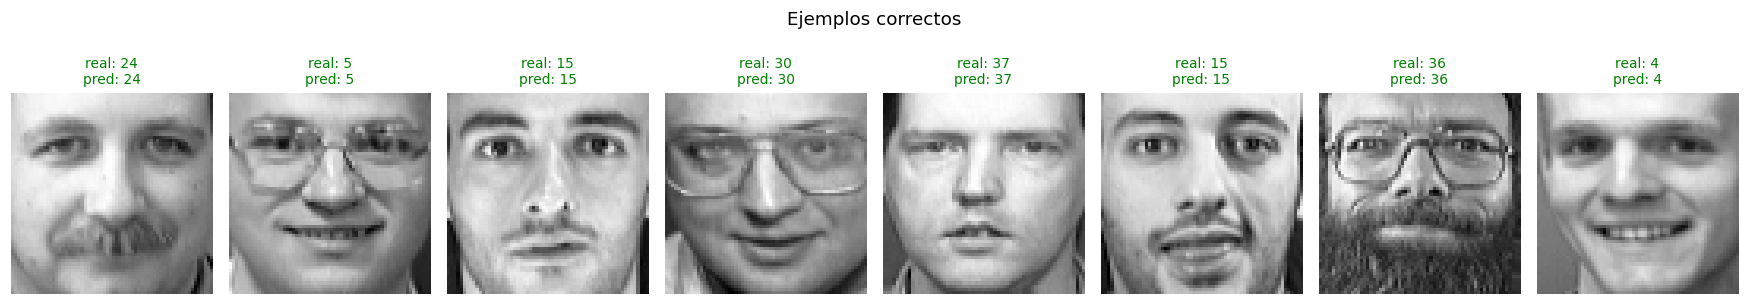

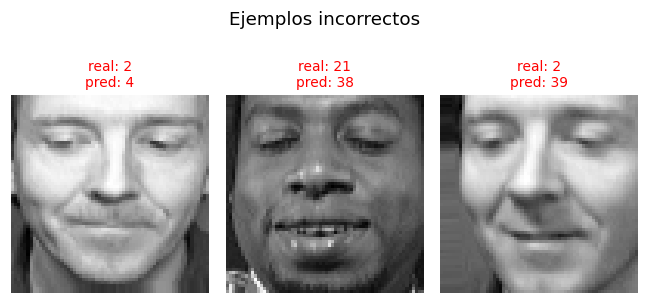

In [15]:
def mostrar_ejemplos(indices, titulo, n=8):
    indices = indices[:n]
    fig, axes = plt.subplots(1, len(indices), figsize=(2 * len(indices), 2.6))
    if len(indices) == 1: axes = [axes]
    for ax, idx in zip(axes, indices):
        ax.imshow(X_test[idx].reshape(h, w), cmap="gray")
        ax.set_title(f"real: {y_test[idx]}\npred: {mejor_pred[idx]}", fontsize=9,
                     color="green" if mejor_pred[idx] == y_test[idx] else "red")
        ax.axis("off")
    plt.suptitle(titulo, y=1.08)
    plt.tight_layout(); plt.show()

aciertos = np.where(mejor_pred == y_test)[0]
mostrar_ejemplos(aciertos, "Ejemplos correctos")
if len(errores) > 0:
    mostrar_ejemplos(errores, "Ejemplos incorrectos")
else:
    print("¡No hubo errores en el conjunto de prueba!")

## 9. Probando con una cara "desconocida"

Un sistema de reconocimiento real también debe poder decir *"no reconozco a esta persona"*. Una forma simple de hacerlo sin redes neuronales es fijar un **umbral de distancia**: si la cara de prueba está muy lejos de todas las caras de entrenamiento en el espacio de eigenfaces, se marca como desconocida.

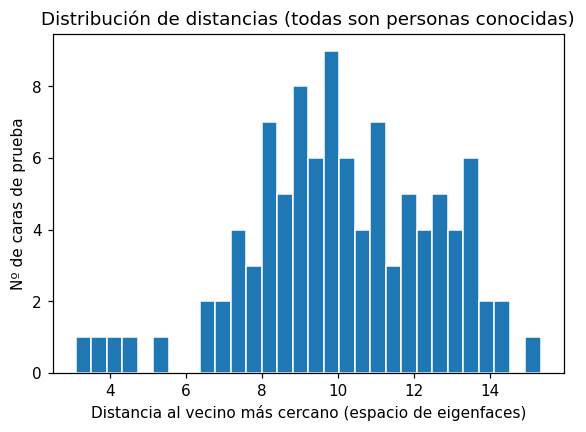

Umbral propuesto: 14.10
Con este umbral, se marcarían como 'desconocidas' 3 de 100 caras de prueba.


In [16]:
from sklearn.neighbors import NearestNeighbors

vecino = NearestNeighbors(n_neighbors=1).fit(Z_train)
distancias, _ = vecino.kneighbors(Z_test)
distancias = distancias.ravel()

plt.figure(figsize=(6, 4))
plt.hist(distancias, bins=30, color="tab:blue", edgecolor="white")
plt.xlabel("Distancia al vecino más cercano (espacio de eigenfaces)")
plt.ylabel("Nº de caras de prueba")
plt.title("Distribución de distancias (todas son personas conocidas)")
plt.show()

UMBRAL = np.percentile(distancias, 97)   # ejemplo: marcar el 3% más lejano como "desconocido"
print(f"Umbral propuesto: {UMBRAL:.2f}")
print(f"Con este umbral, se marcarían como 'desconocidas' "
      f"{(distancias > UMBRAL).sum()} de {len(distancias)} caras de prueba.")

En este experimento todas las caras de prueba pertenecen a personas que sí están en el entrenamiento, así que el umbral solo sirve para mostrar la idea. En un sistema real, el umbral se calibraría con ejemplos de personas verdaderamente desconocidas.

## 10. Hallazgos y conclusiones

Los números exactos de tu ejecución (varianza explicada, exactitud, número de errores) quedan impresos en las celdas de arriba; aquí se resume cómo interpretarlos. En experimentos publicados con Olivetti Faces usando PCA + KNN/SVM, es normal llegar a una exactitud alta (por lo general por encima del 90 %, y a menudo cercana al 95-100 %), porque las 400 fotos están tomadas en condiciones bastante controladas.

### 1. Compresión lograda por PCA
- Cada rostro pasó de **4.096 píxeles** a **150 números** (o menos, según lo que muestre la curva de varianza acumulada de la sección 5). Revisa cuántos componentes hicieron falta para llegar al 90 %, 95 % y 99 % de la varianza en tu ejecución: normalmente el codo aparece bastante antes de los 150 componentes fijados, lo que confirma que hay margen de sobra.
- Esa compresión es la que hace viable comparar caras con un clasificador clásico (KNN, SVM) en vez de trabajar directamente con miles de píxeles.

### 2. Qué muestran las eigenfaces
- Las primeras eigenfaces (mayor varianza explicada) suelen capturar patrones globales: iluminación general, contraste entre luces y sombras, forma general de la cara.
- Las eigenfaces siguientes capturan detalles más locales (ojos, boca, presencia de lentes). Revisa si en tu ejecución alguna eigenface se ve claramente asociada a "usar o no lentes", un rasgo muy presente en Olivetti.
- Ninguna eigenface "es" una persona: cada rostro es una combinación (con pesos positivos o negativos) de todas ellas más el rostro promedio.

### 3. Reconstrucción vs. número de componentes
- Con pocos componentes (10-30) la reconstrucción es borrosa y genérica, parecida al rostro promedio.
- A partir de 60-100 componentes la reconstrucción suele ser casi indistinguible del original a simple vista, coherente con que esa cantidad de componentes ya explica la mayoría de la varianza.

### 4. KNN vs. SVM lineal
- Compara la exactitud de validación cruzada y de prueba de ambos modelos (sección 7 y 8). En datasets con muchas clases y pocas muestras por clase (40 personas, 10 fotos cada una) es común que ambos rindan de forma parecida y muy alta, porque las clases quedan bastante separadas en el espacio de eigenfaces.
- KNN es el clasificador "clásico" del método Eigenfaces original: no necesita entrenar pesos, solo comparar distancias.
- SVM lineal suele ser más robusto cuando dos personas tienen rasgos parecidos, porque encuentra el hiperplano que mejor separa las clases en vez de depender de un solo vecino.

### 5. Errores del modelo
- Si hubo errores en el conjunto de prueba, revisa los ejemplos incorrectos de la sección 8: normalmente ocurren entre personas con **gestos, lentes o iluminación muy distinta** entre sus propias 10 fotos, lo que hace que una foto de esa persona quede "lejos" de las otras fotos de sí misma en el espacio de eigenfaces.
- Con solo 10 fotos por persona (7-8 para entrenar tras el split), el clasificador tiene poca variabilidad para aprender a cada individuo; en un sistema real conviene tener más fotos por persona y en condiciones variadas.

### 6. Sobre el "no lo reconozco"
- El experimento de la sección 9 solo ilustra la idea de un umbral de distancia; como todas las caras de prueba pertenecen a personas conocidas, no mide una tasa real de rechazo. Para desplegar esto en producción habría que calibrar el umbral con fotos de personas genuinamente fuera del dataset de entrenamiento, y lo ideal sería reportar una curva ROC (tasa de aceptación falsa vs. tasa de rechazo falso).

### 7. Por qué esto cumple la restricción de "sin redes neuronales"
- Todo el sistema se construye con **álgebra lineal clásica** (PCA = descomposición en valores/vectores propios de la matriz de covarianza) y clasificadores estadísticos tradicionales (KNN, SVM lineal). No hay backpropagation ni capas entrenadas por descenso de gradiente.

**Conclusión:** PCA logra comprimir cada rostro de 4.096 píxeles a unas pocas decenas de eigenfaces conservando casi toda la información relevante para distinguir personas, y un clasificador simple sobre ese espacio reducido (KNN o SVM lineal) alcanza una exactitud alta sin necesidad de redes neuronales. La principal limitación es la poca cantidad de fotos por persona, que deja poco margen para aprender variaciones extremas de pose o iluminación.